In [1]:
import torch
from torch import nn
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torch.nn.utils.prune as prune

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchmetrics import Accuracy

import torch.optim as optim

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import random
import copy
import gc
import math

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from resnet_18 import *

import cv2
import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
from math import ceil

from craft.craft_torch import Craft, torch_to_numpy

import matplotlib
import colorsys

In [2]:
print(torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

True


In [3]:
model_architecture = 'resnet18' 
checkpoint_path = '../models/0_model_lt.pth.tar'

# model = timm.create_model(model_architecture,pretrained=False,num_classes=10 )
model= resnet_18()
loaded_object = torch.load(checkpoint_path, map_location=device, weights_only=False)
state_dict = loaded_object.state_dict()
model.load_state_dict(state_dict)
model = model.eval().to(device)

In [4]:
# Resolve the data configuration
configuration = resolve_data_config({}, model=model)
# Create an image transformation pipeline
transform = create_transform(**configuration)
# Utility to convert tensor to PIL Image.
to_pil = transforms.ToPILImage()

# Split the model into a feature extractor (g) and a classifier (h)
# the convolutional backbone for feature extraction.
g = nn.Sequential(
    model.conv1,
    model.bn1,
    model.relu,
    model.maxpool,
    model.layer1,
    model.layer2,
    model.layer3,
    model.layer4
)

# the head for classification.
h = nn.Sequential(
    model.global_pool,
    nn.Flatten(1), # Flattens the output of the pool layer for the fc layer
    model.fc
) 

In [5]:
springer_class = 1 # imagenette class for springer

# loading some images of springers !
images = np.load('collected_images/springer.npz')['images']
images_preprocessed = torch.from_numpy(images)

images_preprocessed.shape

torch.Size([500, 3, 224, 224])

In [6]:
craft = Craft(input_to_latent = g,
              latent_to_logit = h,
              number_of_concepts = 10, # The desired number of visual concepts to discover.
              patch_size = 64, # The pixel dimensions (64x64) of the image patches used to represent concepts.
              batch_size = 64, # The number of images to process at a time.
              device = device)

# returns the image patches that best represent each concept and the concept weights.
image_patches, patches_second, w = craft.fit(images_preprocessed)
image_patches = np.moveaxis(torch_to_numpy(image_patches), 1, -1)

image_patches.shape, patches_second.shape, w.shape

((8000, 64, 64, 3), (8000, 10), (10, 512))

In [7]:
# Use the CRAFT model to calculate the importance of each discovered concept
importances = craft.estimate_importance(images_preprocessed, class_id=springer_class)

Concept 5  has an importance value of  0.64216954
Concept 4  has an importance value of  0.019344734
Concept 1  has an importance value of  0.011518365
Concept 3  has an importance value of  0.0105415555
Concept 8  has an importance value of  0.0012882522


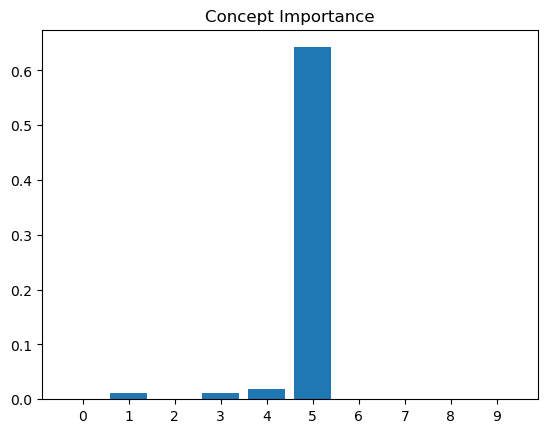

In [8]:
plt.bar(range(len(importances)), importances)
plt.xticks(range(len(importances)))
plt.title("Concept Importance")

# Identify the Top 5 Most Influential Concepts
most_important_concepts = np.argsort(importances)[::-1][:5]

for c_id in most_important_concepts:
  print("Concept", c_id, " has an importance value of ", importances[c_id])

Concept 5  has an importance value of  0.64216954


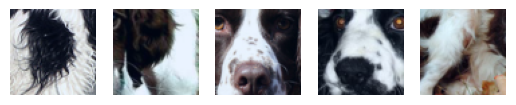




Concept 4  has an importance value of  0.019344734


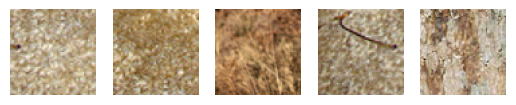




Concept 1  has an importance value of  0.011518365


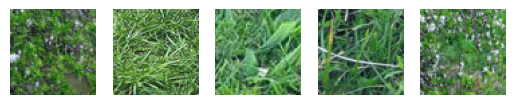




Concept 3  has an importance value of  0.0105415555


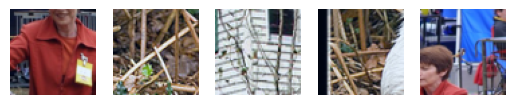




Concept 8  has an importance value of  0.0012882522


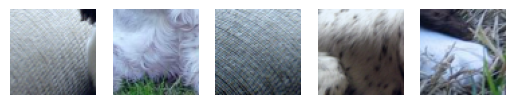

In [9]:
import os
row_images = 5
output_dir = 'concept_visualizations/prune_70/church'
os.makedirs(output_dir, exist_ok=True)

def show(img, **kwargs):
    """
    Prepares and displays an image using Matplotlib.
    """
    img = np.array(img)
    if img.shape[0] == 3:
        # Transpose to (H, W, C) for Matplotlib
        img = img.transpose(1, 2, 0)
        
    # Normalize the image data to the [0, 1] range to ensure proper display.
    img -= img.min();img /= img.max()
    plt.imshow(img, **kwargs); plt.axis('off')

# Iterate through the indices of the most important concepts found earlier.
for c_id in most_important_concepts:
    # For the current concept find the image crops that activate it the most.
    best_crops_ids = np.argsort(patches_second[:, c_id])[::-1][:row_images]
    # Use the top indices to select the actual image patches from the `image_patches` array.
    best_crops = image_patches[best_crops_ids]
    
    print("Concept", c_id, " has an importance value of ", importances[c_id])
    
    # Display the top `row_images` in a row.
    for i in range(row_images):
        plt.subplot(ceil(row_images/5), 5, i+1)
        show(best_crops[i])
        
    save_path = os.path.join(output_dir, f'concept_{c_id}.png')
    # Save the figure to the specified file path
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print('\n\n')